# ELT pupil demo from `HarmoniResiduals`

This notebook demonstrates how to build an ELT pupil **directly from your
`HarmoniResiduals` object**, instead of loading a FITS pupil file.

The logic is:

1. build the ELT pupil sampling grid,
2. instantiate `HarmoniResiduals(grid=pupil_grid)`,
3. derive a binary transmission mask from the residual-screen support,
4. use that mask inside `ArbitraryAperture`,
5. propagate to the focal plane and display the PSF.

This matches the usage pattern:

```python
atm_res = HarmoniResiduals(grid=pupil_grid)
pupil_mask = atm_res.datacube[0, ...].clone()
pupil_mask[pupil_mask != 0] = 1
```

A slightly cleaner equivalent, used below, is:

```python
pupil_mask = (atm_res.datacube[0] != 0).to(torch.float32)
```

because it makes it explicit that we are extracting the **support** of the
residual screen rather than using the residual OPD values themselves.

> **Note**
>
> This example only works if the HARMONI residual phase-screen data are available locally as FITS files and can be loaded by `HarmoniResiduals`.
>
> The ELT pupil is inferred from the support of the first residual phase screen:
>
> ```python
> atm_res = HarmoniResiduals(grid=pupil_grid)
> pupil_mask = (atm_res.datacube[0] != 0).to(torch.float32)
> ```
>
> If the residual FITS dataset is not installed or its path is not configured correctly, this example will not run.

In [7]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import Band, Spectrum
from fiatlux.core.source import PlaneWave

from fiatlux.optics.elements.mask import ArbitraryAperture, CircularAperture
from fiatlux.optics.propagator import MFTPropagator
from fiatlux.system.optical_system import SerialSystem

from fiatlux.optics.elements.mask import HarmoniResiduals

## Define the ELT pupil grid

Use the pupil diameter and sampling consistent with your HARMONI / Fiatlux
simulations.

Here we use:

- `D = 38.542 m`
- `N_pupil = 400`

In [8]:
D = 38.542
N_pupil = 400

pupil_grid = Grid(
    nx=N_pupil,
    ny=N_pupil,
    dx=D / N_pupil,
    dy=D / N_pupil,
)

print("Pupil grid:", pupil_grid)
print("Pixel size [m]:", pupil_grid.dx)

Pupil grid: Grid(nx=400, ny=400, dx=0.09635500000000001, dy=0.09635500000000001, device=device(type='cpu'))
Pixel size [m]: 0.09635500000000001


## Instantiate `HarmoniResiduals`

This object contains residual phase screens sampled on the same pupil grid.

In [9]:
atm_res = HarmoniResiduals(grid=pupil_grid)

print("Residual datacube shape:", atm_res.datacube.shape)

Residual datacube shape: torch.Size([4000, 400, 400])


## Build the ELT transmission mask from the residual-screen support

Your current method is:

```python
pupil_mask = atm_res.datacube[0, ...].clone()
pupil_mask[pupil_mask != 0] = 1
```

Below we build the same binary support more explicitly.

In [10]:
pupil_mask = (atm_res.datacube[0] != 0).to(torch.float32)

print("Pupil mask shape:", pupil_mask.shape)
print("Unique values:", torch.unique(pupil_mask))

Pupil mask shape: torch.Size([400, 400])
Unique values: tensor([0., 1.])


## Display the extracted ELT pupil

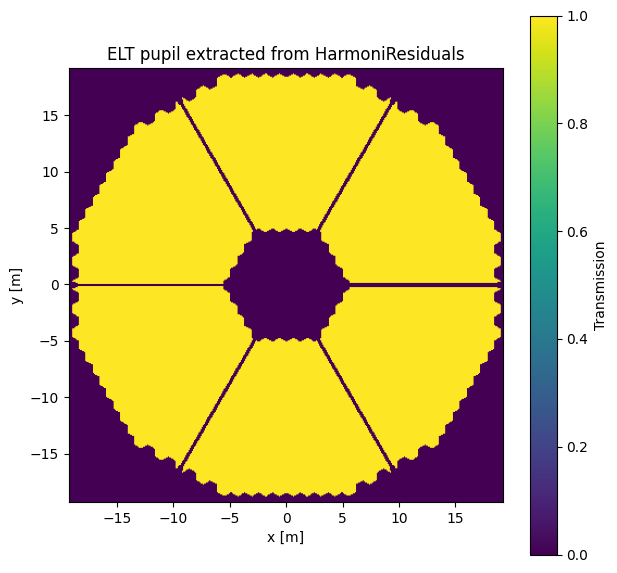

In [11]:
extent = [
    float(pupil_grid.x.min()),
    float(pupil_grid.x.max()),
    float(pupil_grid.y.min()),
    float(pupil_grid.y.max()),
]

plt.figure(figsize=(7, 7))
plt.imshow(
    pupil_mask.cpu(),
    origin="lower",
    extent=extent,
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("ELT pupil extracted from HarmoniResiduals")
plt.colorbar(label="Transmission")
plt.show()

## Create a monochromatic source

We use a simple monochromatic point source at

\[
\lambda = 1.65\,\mu\mathrm{m}.
\]

A zero-width `Band` gives us one wavelength sample.

In [12]:
wavelength = 1.65e-6

band = Band(
    central_wavelength=wavelength,
    delta_wavelength=0.0,
    f0=1.1e12,
)

spectrum = Spectrum(
    magnitude=0,
    band=band,
    samples=1,
)

source = PlaneWave(spectrum=spectrum)

print("Wavelength [µm]:", float(spectrum.wavelengths[0]) * 1e6)

Wavelength [µm]: 1.6499999446750735


## Define the focal-plane grid

We choose a focal-plane sampling of 4 pixels per \(\lambda/D\).

In [13]:
focal_length = 1.0
N_focal = 512
pixels_per_lambda_D = 4

focal_grid = Grid(
    nx=N_focal,
    ny=N_focal,
    dx=focal_length * wavelength / D / pixels_per_lambda_D,
    dy=focal_length * wavelength / D / pixels_per_lambda_D,
)

propagator = MFTPropagator(
    focal_length=focal_length,
    output_grid=focal_grid,
)

## Create a Fiatlux aperture from the extracted pupil mask

In [14]:
elt_aperture = ArbitraryAperture(
    grid=pupil_grid,
    transmission=pupil_mask,
)

## Propagate the ELT pupil to the focal plane

In [15]:
elt_system = SerialSystem(
    elements=[
        elt_aperture,
        propagator,
    ]
)

elt_result = elt_system.run(source=source)

## Inspect the field immediately after the pupil

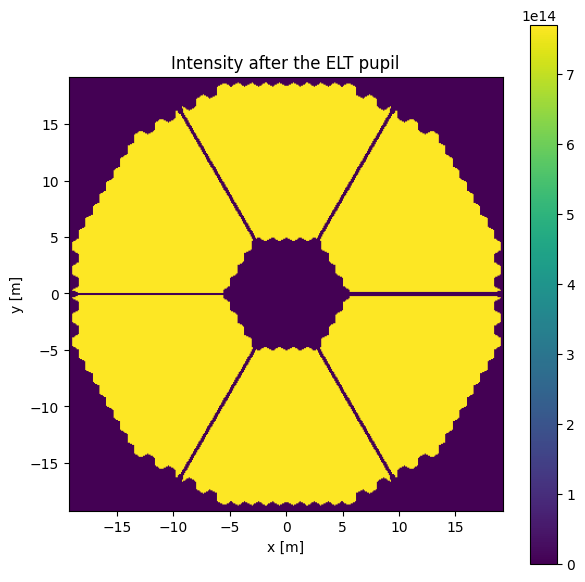

In [16]:
field_after_pupil = elt_result.field_at(elt_aperture)

plt.figure(figsize=(7, 7))
plt.imshow(
    field_after_pupil.intensity()[0].cpu(),
    origin="lower",
    extent=extent,
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Intensity after the ELT pupil")
plt.colorbar()
plt.show()

## Compute and display the ELT PSF

In [17]:
focal_field = elt_result.field_at(propagator)

elt_psf = focal_field.intensity().sum(dim=0)
elt_psf = elt_psf / elt_psf.max()

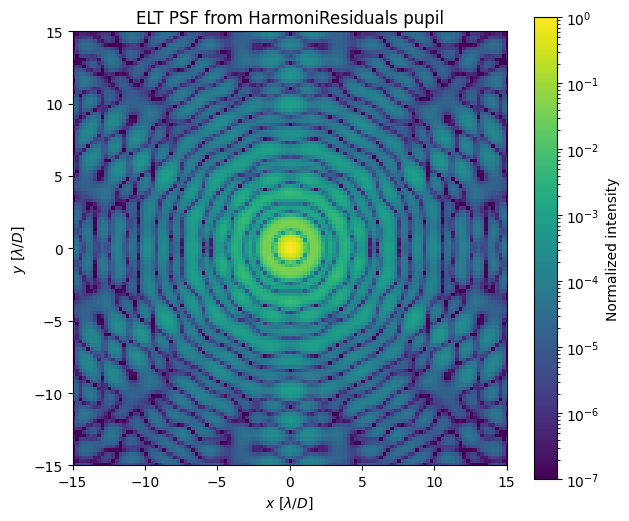

In [18]:
extent_lambda_D = [
    float(focal_grid.x.min() / (focal_length * wavelength / D)),
    float(focal_grid.x.max() / (focal_length * wavelength / D)),
    float(focal_grid.y.min() / (focal_length * wavelength / D)),
    float(focal_grid.y.max() / (focal_length * wavelength / D)),
]

plt.figure(figsize=(7, 6))
plt.imshow(
    elt_psf.cpu(),
    origin="lower",
    extent=extent_lambda_D,
    norm=LogNorm(vmin=1e-7, vmax=1),
)

plt.xlabel(r"$x\ [\lambda/D]$")
plt.ylabel(r"$y\ [\lambda/D]$")
plt.title("ELT PSF from HarmoniResiduals pupil")
plt.colorbar(label="Normalized intensity")

plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.show()

## Compare with a clear circular aperture

This makes the effect of the central obscuration and spiders immediately visible.

In [19]:
circular_aperture = CircularAperture(
    grid=pupil_grid,
    radius=D / 2,
)

circular_system = SerialSystem(
    elements=[
        circular_aperture,
        propagator,
    ]
)

circular_result = circular_system.run(source=source)

circular_psf = circular_result.field_at(propagator).intensity().sum(dim=0)
circular_psf = circular_psf / circular_psf.max()

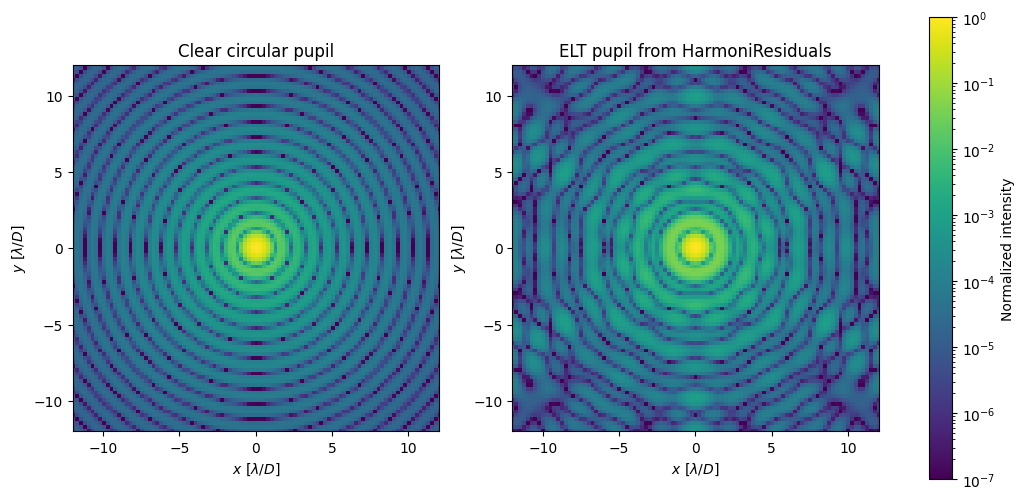

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, image, title in [
    (axes[0], circular_psf, "Clear circular pupil"),
    (axes[1], elt_psf, "ELT pupil from HarmoniResiduals"),
]:
    im = ax.imshow(
        image.cpu(),
        origin="lower",
        extent=extent_lambda_D,
        norm=LogNorm(vmin=1e-7, vmax=1),
    )

    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_xlabel(r"$x\ [\lambda/D]$")
    ax.set_ylabel(r"$y\ [\lambda/D]$")
    ax.set_title(title)

fig.colorbar(im, ax=axes, label="Normalized intensity")
plt.show()

## Notes

A future improvement in Fiatlux would be for `HarmoniResiduals` to expose the
pupil support explicitly, for example as:

```python
atm_res.pupil
```

or

```python
atm_res.support
```

That would avoid deriving the telescope transmission mask from the values of one
residual phase screen.